<a href="https://colab.research.google.com/github/SiddyCurry/diabetesAIRP/blob/main/AIRP_Diabetes_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [186]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
!pip install scikit-learn
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.metrics import *
from sklearn.linear_model import LinearRegression
from sklearn import metrics
data = pd.read_csv('https://raw.githubusercontent.com/frontiertechinstitute/datasets/refs/heads/main/AIHSRP%20Diabetes/diabetes_012_health_indicators_BRFSS2015.csv')

In [44]:
data.head()
data.info()
#data = data[data['MentHlth'] != 0]
#data = data[data['PhysHlth'] != 0]
data.head(15)

<class 'pandas.core.frame.DataFrame'>
Index: 43933 entries, 0 to 253673
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Diabetes_012          43933 non-null  float64
 1   HighBP                43933 non-null  float64
 2   HighChol              43933 non-null  float64
 3   CholCheck             43933 non-null  float64
 4   BMI                   43933 non-null  float64
 5   Smoker                43933 non-null  float64
 6   Stroke                43933 non-null  float64
 7   HeartDiseaseorAttack  43933 non-null  float64
 8   PhysActivity          43933 non-null  float64
 9   Fruits                43933 non-null  float64
 10  Veggies               43933 non-null  float64
 11  HvyAlcoholConsump     43933 non-null  float64
 12  AnyHealthcare         43933 non-null  float64
 13  NoDocbcCost           43933 non-null  float64
 14  GenHlth               43933 non-null  float64
 15  MentHlth              4

,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
8,2.0,1.0,1.0,1.0,30.0,1.0,0.0,1.0,0.0,1.0,...,1.0,0.0,5.0,30.0,30.0,1.0,0.0,9.0,5.0,1.0
14,0.0,0.0,1.0,1.0,33.0,1.0,1.0,0.0,1.0,0.0,...,1.0,1.0,4.0,30.0,28.0,0.0,0.0,4.0,6.0,2.0
21,0.0,1.0,1.0,1.0,38.0,1.0,0.0,0.0,0.0,1.0,...,1.0,0.0,5.0,15.0,30.0,1.0,0.0,13.0,2.0,3.0
28,2.0,1.0,1.0,1.0,27.0,1.0,0.0,0.0,0.0,1.0,...,1.0,0.0,4.0,20.0,20.0,1.0,0.0,8.0,4.0,7.0
36,0.0,1.0,1.0,1.0,24.0,1.0,0.0,0.0,1.0,0.0,...,1.0,0.0,3.0,5.0,3.0,1.0,1.0,8.0,4.0,3.0
42,0.0,0.0,0.0,1.0,28.0,1.0,1.0,0.0,0.0,1.0,...,1.0,1.0,4.0,15.0,30.0,1.0,0.0,7.0,4.0,3.0
48,0.0,1.0,1.0,1.0,37.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,3.0,30.0,2.0,1.0,1.0,10.0,5.0,6.0
50,0.0,1.0,1.0,1.0,30.0,1.0,0.0,1.0,1.0,0.0,...,1.0,0.0,4.0,10.0,17.0,1.0,0.0,9.0,4.0,1.0


In [ ]:
data.duplicated().sum()
data.corr()

,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
Diabetes_012,1.000000,0.271596,0.209085,0.067546,0.224379,0.062914,0.107179,0.180272,-0.121947,-0.042192,...,0.015410,0.035436,0.302587,0.073507,0.176287,0.224239,0.031040,0.185026,-0.130517,-0.171483
HighBP,0.271596,1.000000,0.298199,0.098508,0.213748,0.096991,0.129575,0.209361,-0.125267,-0.040555,...,0.038425,0.017358,0.300530,0.056456,0.161212,0.223618,0.052207,0.344452,-0.141358,-0.171235
HighChol,0.209085,0.298199,1.000000,0.085642,0.106722,0.091299,0.092620,0.180765,-0.078046,-0.040859,...,0.042230,0.013310,0.208426,0.062069,0.121751,0.144672,0.031205,0.272318,-0.070802,-0.085459
CholCheck,0.067546,0.098508,0.085642,1.000000,0.034495,-0.009929,0.024158,0.044206,0.004190,0.023849,...,0.117626,-0.058255,0.046589,-0.008366,0.031775,0.040585,-0.022115,0.090321,0.001510,0.014259
BMI,0.224379,0.213748,0.106722,0.034495,1.000000,0.013804,0.020153,0.052904,-0.147294,-0.087518,...,-0.018471,0.058206,0.239185,0.085310,0.121141,0.197078,0.042950,-0.036618,-0.103932,-0.100069
Smoker,0.062914,0.096991,0.091299,-0.009929,0.013804,1.000000,0.061173,0.114441,-0.087401,-0.077666,...,-0.023251,0.048946,0.163143,0.092196,0.116460,0.122463,0.093662,0.120641,-0.161955,-0.123937
Stroke,0.107179,0.129575,0.092620,0.024158,0.020153,0.061173,1.000000,0.203002,-0.069151,-0.013389,...,0.008776,0.034804,0.177942,0.070172,0.148944,0.176567,0.002978,0.126974,-0.076009,-0.128599
HeartDiseaseorAttack,0.180272,0.209361,0.180765,0.044206,0.052904,0.114441,0.203002,1.000000,-0.087299,-0.019790,...,0.018734,0.031000,0.258383,0.064621,0.181698,0.212709,0.086096,0.221618,-0.099600,-0.141011
PhysActivity,-0.121947,-0.125267,-0.078046,0.004190,-0.147294,-0.087401,-0.069151,-0.087299,1.000000,0.142756,...,0.035505,-0.061638,-0.266186,-0.125587,-0.219230,-0.253174,0.032482,-0.092511,0.199658,0.198539
Fruits,-0.042192,-0.040555,-0.040859,0.023849,-0.087518,-0.077666,-0.013389,-0.019790,0.142756,1.000000,...,0.031544,-0.044243,-0.103854,-0.068217,-0.044633,-0.048352,-0.091175,0.064547,0.110187,0.079929


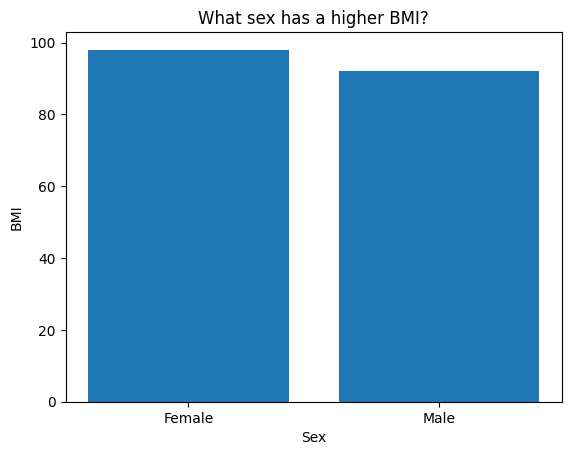

In [28]:
fig, ax = plt.subplots()
ax.bar(data['Sex'], data['BMI'])
ax.set_xticks([0, 1])
ax.set_xticklabels(['Female', 'Male'])
plt.title('What sex has a higher BMI?')
plt.xlabel('Sex')
plt.ylabel('BMI')
plt.show()

<Axes: title={'center': 'MentHlth'}, xlabel='Diabetes_012'>

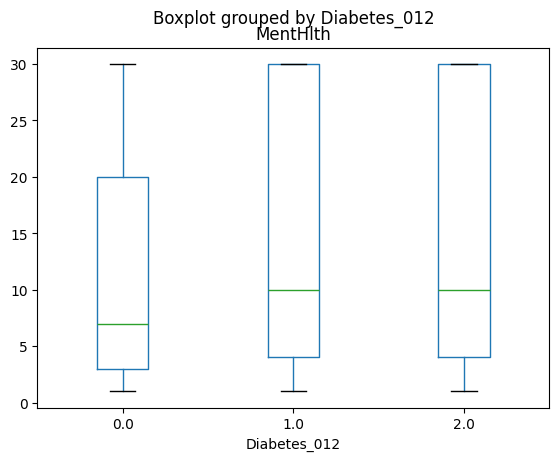

In [30]:
ax.set_title('Box Plot comparing Mental Health and Diabetes')
ax.set_xlabel('Stage of Diabetes')
ax.set_ylabel('Mental Health')
data.boxplot(column = 'MentHlth', by = 'Diabetes_012', grid = False)


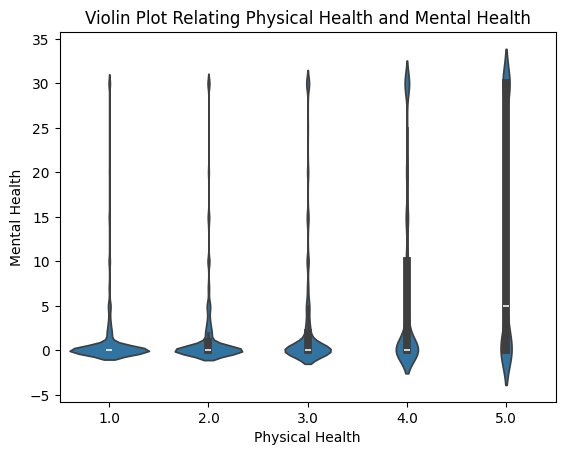

In [ ]:
sns.violinplot(x=data['GenHlth'], y=data['MentHlth'])
plt.title('Violin Plot Relating Physical Health and Mental Health')
plt.xlabel('Physical Health')
plt.ylabel('Mental Health')
plt.show()

In [178]:
# Linear Regression
features = data[['HighBP', 'BMI', 'GenHlth', 'HighChol', 'Age', 'DiffWalk', 'Income', 'HeartDiseaseorAttack']]
labels = data['Diabetes_012']

In [179]:
X_train, X_test, y_train, y_test = train_test_split(features, labels, test_size=0.2, random_state = 42)
model = LinearRegression()

In [180]:
model.fit(X_train, y_train)

LinearRegression()

In [181]:
pred = model.predict(X_test)

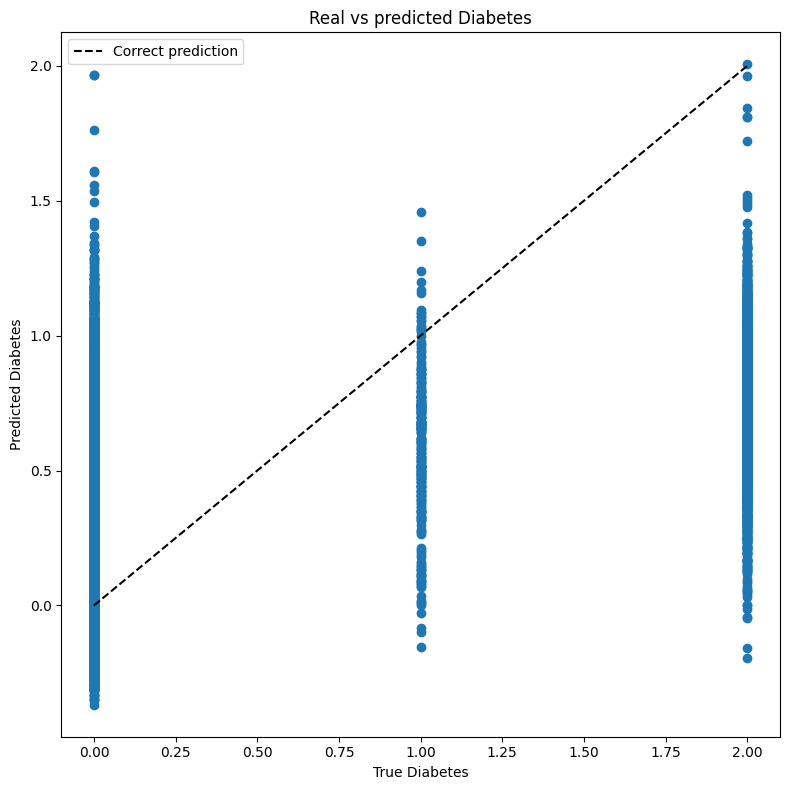

In [170]:
plt.figure(figsize=(8, 8))


plt.scatter(y_test, pred)
plt.plot([y_train.min(), y_train.max()], [y_test.min(), y_test.max()], '--k', label="Correct prediction")


plt.axis('tight')


plt.xlabel('True Diabetes')
plt.ylabel('Predicted Diabetes')
plt.title("Real vs predicted Diabetes")

plt.legend()
plt.tight_layout()


In [182]:
print('R2 score: ' , r2_score(y_test, pred))
print('MSE: ' , mean_squared_error(y_test, pred))
print('MAE: ' , mean_absolute_error(y_test, pred))

R2 score:  0.19226219919501053
MSE:  0.5277661028342612
MAE:  0.5699371465296629


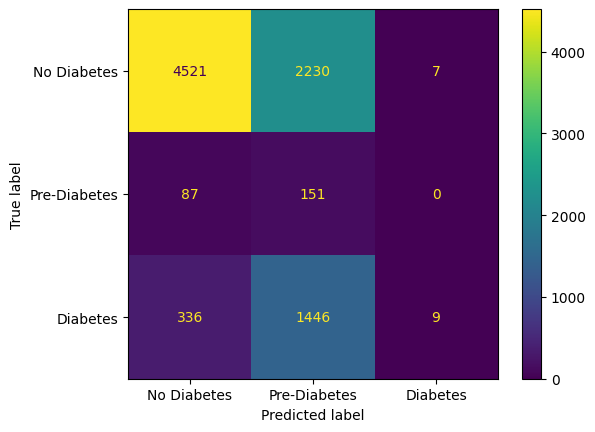

In [190]:
pred_rounded = np.round(pred).astype(int)
pred_rounded = np.clip(pred_rounded, 0, 2)
metrics.ConfusionMatrixDisplay.from_predictions(y_test, pred_rounded, display_labels = ['No Diabetes', 'Pre-Diabetes', 'Diabetes'])

plt.show()
